In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

In [3]:
import re
data_path = 'creditcard_processed.csv'
df = pd.read_csv(data_path)

# Xóa cột Unnamed: 0 nếu tồn tại và loại bỏ ký tự đặc biệt trong tên cột cho LightGBM
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df = df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (284807, 31)


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [5]:
# Tách feature và target
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (227845, 30), y_train shape: (227845,)
X_test shape: (56962, 30), y_test shape: (56962,)


In [6]:
# 1. Original (Mặc định)
# 2. SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. Random UnderSampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

# 4. Random OverSampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Original label distribution:", np.bincount(y_train))
print("SMOTE label distribution:", np.bincount(y_train_smote))
print("UnderSampling label distribution:", np.bincount(y_train_rus))
print("OverSampling label distribution:", np.bincount(y_train_ros))

datasets = {
    'Original': (X_train, y_train),
    'SMOTE': (X_train_smote, y_train_smote),
    'UnderSampling': (X_train_rus, y_train_rus),
    'OverSampling': (X_train_ros, y_train_ros)
}

Original label distribution: [227451    394]
SMOTE label distribution: [227451 227451]
UnderSampling label distribution: [394 394]
OverSampling label distribution: [227451 227451]


Khởi tạo Hàm Đánh giá

In [7]:
def evaluate_model(y_true, y_pred, model_name, prep_method):
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    print(f"--- {model_name} with {prep_method} ---")
    print(f"Accuracy : {acc:.5f}")
    print(f"Precision: {prec:.5f}")
    print(f"Recall   : {rec:.5f}")
    print(f"F1-Score : {f1:.5f}")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix\n{model_name} ({prep_method})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return {'Model': model_name, 'Method': prep_method, 'F1-Score': f1, 'Accuracy': acc, 'Precision': prec, 'Recall': rec}

global_results = []

Huấn luyện Mô hình: Random Forest

=========== RANDOM FOREST ===========
--- Random Forest with Original ---
Accuracy : 0.99958
Precision: 0.94048
Recall   : 0.80612
F1-Score : 0.86813
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



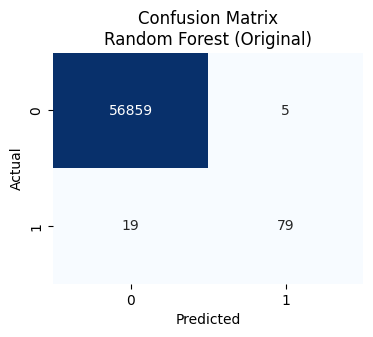

--------------------------------------------------
--- Random Forest with SMOTE ---
Accuracy : 0.99944
Precision: 0.85106
Recall   : 0.81633
F1-Score : 0.83333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



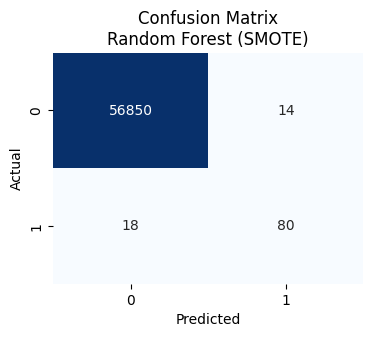

--------------------------------------------------
--- Random Forest with UnderSampling ---
Accuracy : 0.96445
Precision: 0.04228
Recall   : 0.90816
F1-Score : 0.08080
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



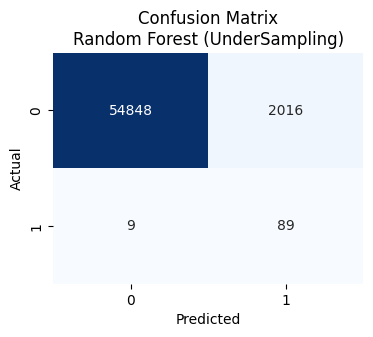

--------------------------------------------------
--- Random Forest with OverSampling ---
Accuracy : 0.99958
Precision: 0.95122
Recall   : 0.79592
F1-Score : 0.86667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.80      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



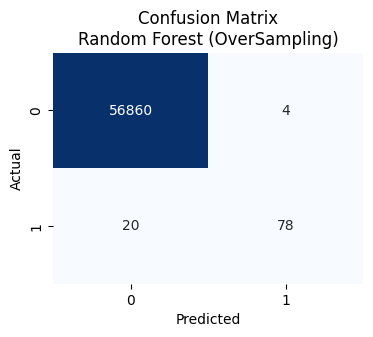

--------------------------------------------------


In [8]:
print("=========== RANDOM FOREST ===========")
m_name = 'Random Forest'
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

for d_name, (X_tr, y_tr) in datasets.items():
    start_time = time.time()
    rf_model.fit(X_tr, y_tr)
    y_pred = rf_model.predict(X_test)
    
    res = evaluate_model(y_test, y_pred, m_name, d_name)
    res['Training Time (s)'] = round(time.time() - start_time, 2)
    global_results.append(res)
    print("-" * 50)

Huấn luyện Mô hình: XGBoost

=========== XGBOOST ===========
--- XGBoost with Original ---
Accuracy : 0.99944
Precision: 0.86667
Recall   : 0.79592
F1-Score : 0.82979
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



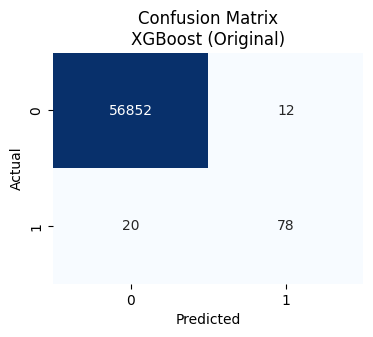

--------------------------------------------------
--- XGBoost with SMOTE ---
Accuracy : 0.99912
Precision: 0.70000
Recall   : 0.85714
F1-Score : 0.77064
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



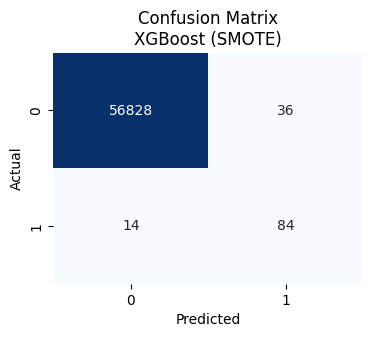

--------------------------------------------------
--- XGBoost with UnderSampling ---
Accuracy : 0.95406
Precision: 0.03335
Recall   : 0.91837
F1-Score : 0.06435
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.03      0.92      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.95      0.97     56962



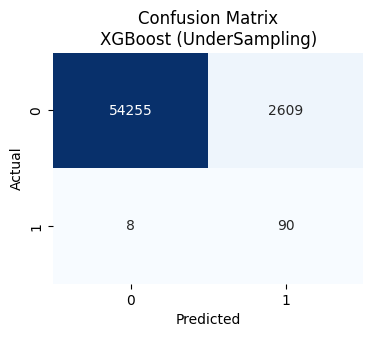

--------------------------------------------------
--- XGBoost with OverSampling ---
Accuracy : 0.99960
Precision: 0.89474
Recall   : 0.86735
F1-Score : 0.88083
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.87      0.88        98

    accuracy                           1.00     56962
   macro avg       0.95      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962



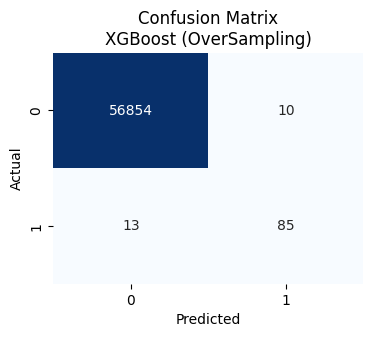

--------------------------------------------------


In [9]:
print("=========== XGBOOST ===========")
m_name = 'XGBoost'
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

for d_name, (X_tr, y_tr) in datasets.items():
    start_time = time.time()
    xgb_model.fit(X_tr, y_tr)
    y_pred = xgb_model.predict(X_test)
    
    res = evaluate_model(y_test, y_pred, m_name, d_name)
    res['Training Time (s)'] = round(time.time() - start_time, 2)
    global_results.append(res)
    print("-" * 50)

Huấn luyện Mô hình: LightGBM

=========== LIGHTGBM ===========
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010561 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain:

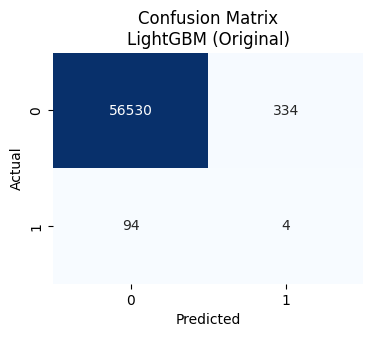

--------------------------------------------------
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020789 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- LightGBM with SMOTE ---
Accuracy : 0.99844
Precision: 0.52761
Recall   : 0.87755
F1-Score : 0.65900
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.88      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



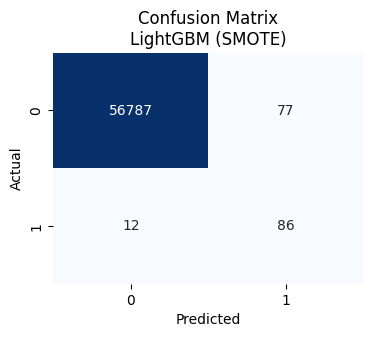

--------------------------------------------------
[LightGBM] [Info] Number of positive: 394, number of negative: 394
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7648
[LightGBM] [Info] Number of data points in the train set: 788, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- LightGBM with UnderSampling ---
Accuracy : 0.95581
Precision: 0.03463
Recall   : 0.91837
F1-Score : 0.06674
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     5

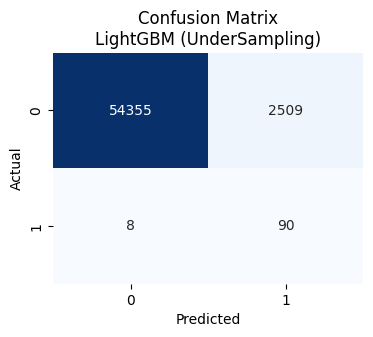

--------------------------------------------------
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027786 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7649
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- LightGBM with OverSampling ---
Accuracy : 0.99937
Precision: 0.78704
Recall   : 0.86735
F1-Score : 0.82524
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



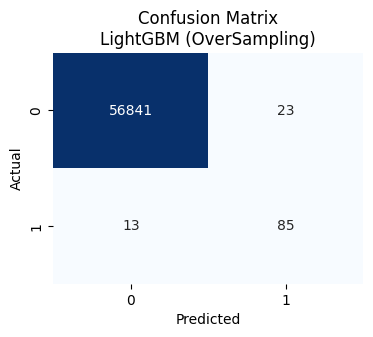

--------------------------------------------------


In [10]:
print("=========== LIGHTGBM ===========")
m_name = 'LightGBM'
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

for d_name, (X_tr, y_tr) in datasets.items():
    start_time = time.time()
    lgb_model.fit(X_tr, y_tr)
    y_pred = lgb_model.predict(X_test)
    
    res = evaluate_model(y_test, y_pred, m_name, d_name)
    res['Training Time (s)'] = round(time.time() - start_time, 2)
    global_results.append(res)
    print("-" * 50)

Tổng hợp Kết quả đánh giá

In [11]:
results_df = pd.DataFrame(global_results)
display(results_df.sort_values(by='F1-Score', ascending=False))

,Model,Method,F1-Score,Accuracy,Precision,Recall,Training Time (s)
7,XGBoost,OverSampling,0.880829,0.999596,0.894737,0.867347,2.10
0,Random Forest,Original,0.868132,0.999579,0.940476,0.806122,37.82
3,Random Forest,OverSampling,0.866667,0.999579,0.951220,0.795918,29.00
1,Random Forest,SMOTE,0.833333,0.999438,0.851064,0.816327,51.47
4,XGBoost,Original,0.829787,0.999438,0.866667,0.795918,1.15
11,LightGBM,OverSampling,0.825243,0.999368,0.787037,0.867347,2.08
5,XGBoost,SMOTE,0.770642,0.999122,0.700000,0.857143,2.26
9,LightGBM,SMOTE,0.659004,0.998438,0.527607,0.877551,1.87
2,Random Forest,UnderSampling,0.080799,0.964450,0.042280,0.908163,0.31
10,LightGBM,UnderSampling,0.066741,0.955813,0.034629,0.918367,0.21


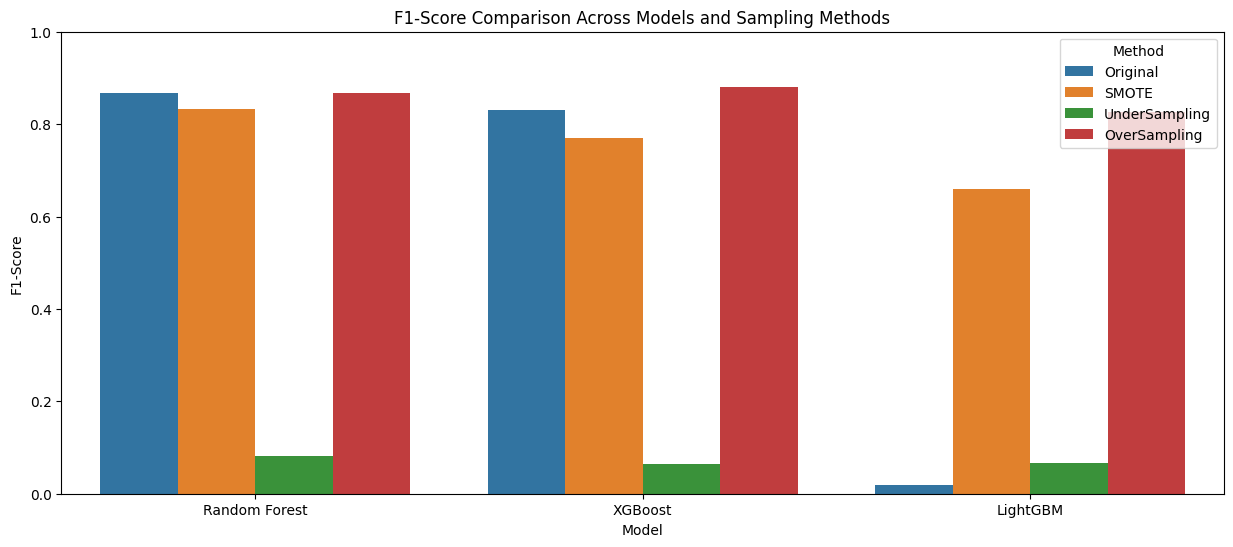

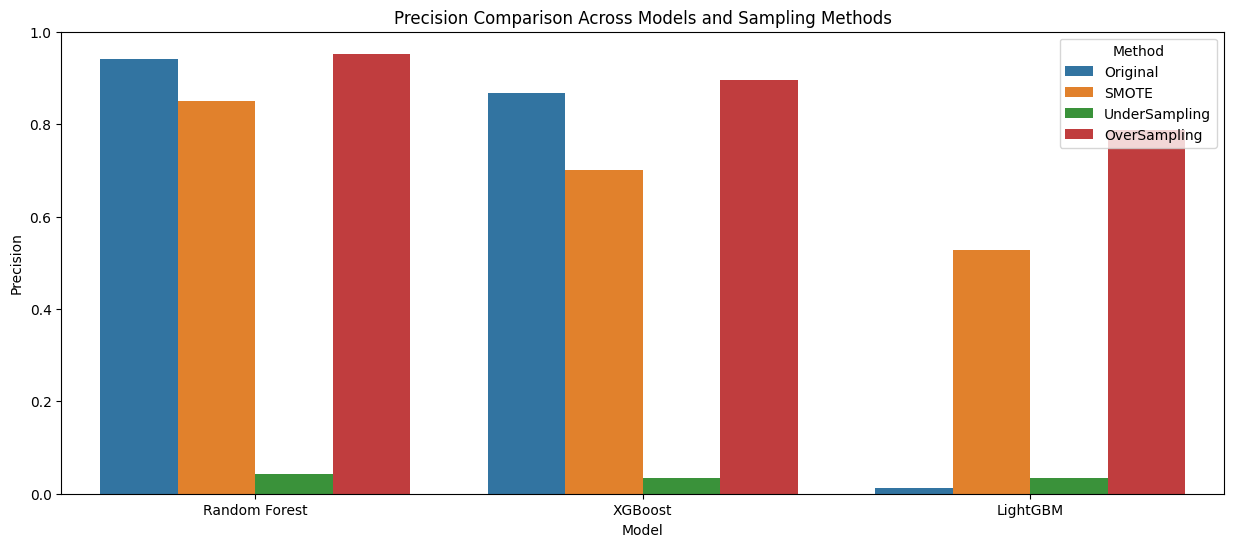

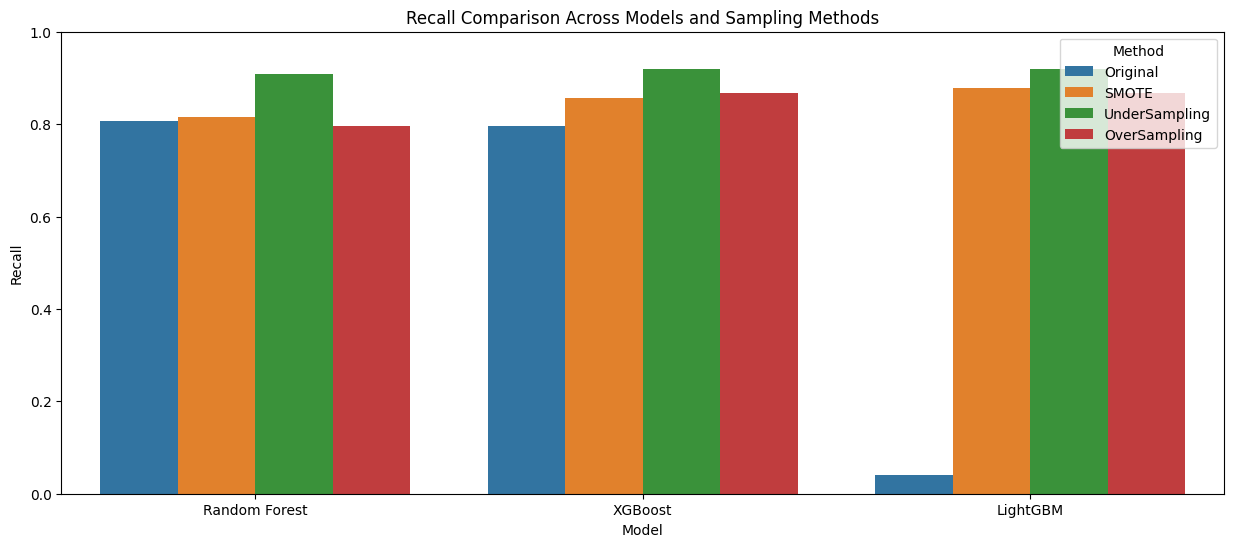

In [12]:
plt.figure(figsize=(15, 6))
sns.barplot(data=results_df, x='Model', y='F1-Score', hue='Method')
plt.title('F1-Score Comparison Across Models and Sampling Methods')
plt.ylim(0, 1.0)
plt.show()

plt.figure(figsize=(15, 6))
sns.barplot(data=results_df, x='Model', y='Precision', hue='Method')
plt.title('Precision Comparison Across Models and Sampling Methods')
plt.ylim(0, 1.0)
plt.show()

plt.figure(figsize=(15, 6))
sns.barplot(data=results_df, x='Model', y='Recall', hue='Method')
plt.title('Recall Comparison Across Models and Sampling Methods')
plt.ylim(0, 1.0)
plt.show()